# Machine Learning Assignment – 2

## Income Classification Using Multiple Machine Learning Models and Streamlit Deployment

### Student Details

**Name:** DEBJIT BISWAS

**BITS ID:** 2025DA04158

**Course:** M.Tech (DSE)

**Subject:** Machine Learning

**Assignment:** Assignment – 2

---

## Objective

The objective of this assignment is to develop and compare multiple machine learning classification models for predicting whether an individual's annual income exceeds \$50,000 based on demographic and employment-related features. The performance of each model will be evaluated using standard classification metrics, and the best-performing model will be deployed using Streamlit Community Cloud.

---

## Models Implemented

1. Logistic Regression
2. Decision Tree Classifier
3. K-Nearest Neighbors (KNN)
4. Gaussian Naive Bayes
5. Random Forest Classifier

---

## Evaluation Metrics

- Accuracy
- AUC Score
- Precision
- Recall
- F1 Score
- Matthews Correlation Coefficient (MCC)

# Dataset Description

## Dataset Name

Adult Income (Census Income Dataset)

## Source

UCI Machine Learning Repository

## Description

The Adult Income dataset is extracted from the 1994 United States Census database. The objective is to predict whether an individual's annual income is greater than \$50,000 using demographic and employment-related information.

## Dataset Statistics

- Total Records: 48,842
- Total Features: 14
- Target Variable: Income (>50K or <=50K)
- Problem Type: Binary Classification

The dataset satisfies the assignment requirement of containing more than 500 instances and at least 12 features.

# Project Workflow

The project follows the following workflow:

1. Import Required Libraries
2. Load Dataset
3. Data Exploration
4. Data Cleaning
5. Missing Value Treatment
6. Exploratory Data Analysis
7. Feature Encoding
8. Train-Test Split
9. Feature Scaling
10. Model Training
11. Model Evaluation
12. Performance Comparison
13. Best Model Selection
14. Save Trained Models
15. Conclusion

In [4]:
# ============================================
# Import Required Libraries
# ============================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import joblib

print("All libraries imported successfully.")

All libraries imported successfully.


# Load the Dataset

In this step, the Adult Income dataset is loaded into a Pandas DataFrame for preprocessing and analysis.

In [6]:
# Load Adult Income Dataset

import pandas as pd

column_names = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

df = pd.read_csv(
    "adult.data",
    header=None,
    names=column_names,
    skipinitialspace=True
)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [7]:
# Display first five records

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [8]:
# Dataset Shape

print("Rows and Columns:", df.shape)

Rows and Columns: (32561, 15)


In [9]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [10]:
# Statistical Summary

df.describe(include='all')

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
count,32561.000000,32561,3.256100e+04,32561,32561.000000,32561,32561,32561,32561,32561,32561.000000,32561.000000,32561.000000,32561,32561
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.581647,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,1077.648844,87.303830,40.437456,NaN,NaN
std,13.640433,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,7385.292085,402.960219,12.347429,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


# Initial Observations

After loading and exploring the dataset, the following observations were made:

- The dataset contains **32,561 records** and **15 columns**.
- It consists of both **numerical** and **categorical** features.
- The target variable is **income**, which has two classes: **<=50K** and **>50K**.
- Some categorical attributes use the symbol **'?'** to represent missing values.
- The dataset requires preprocessing before training machine learning models.
- Feature encoding and scaling will be performed before model implementation.

# Data Preprocessing

Data preprocessing is one of the most important stages in any machine learning project. The Adult Income dataset contains categorical features and missing values represented by the symbol '?'. These issues must be handled before training the machine learning models.

The following preprocessing steps will be performed:

- Check missing values
- Replace '?' with NaN
- Handle missing values
- Remove duplicate records
- Encode categorical variables
- Separate features and target variable

In [13]:
# Check missing values

df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

## Handling Missing Values

The Adult Income dataset represents missing values using the '?' symbol instead of actual null values. Therefore, these symbols are first converted into NaN values so that they can be handled appropriately.

In [15]:
import numpy as np

# Replace '?' with NaN

df.replace("?", np.nan, inplace=True)

df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

## Observation

After replacing '?' with NaN, missing values become visible. These missing values will now be handled using the mode (most frequent value) of each categorical column.

In [17]:
# Fill missing values using mode

for column in df.columns:
    if df[column].dtype == "object":
        df[column].fillna(df[column].mode()[0], inplace=True)

df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

## Duplicate Record Check

Duplicate records can negatively affect model performance. Therefore, duplicate entries are identified and removed before training.

In [19]:
# Check duplicate records

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 24


In [20]:
# Remove duplicate rows

df.drop_duplicates(inplace=True)

print("Dataset Shape After Removing Duplicates :", df.shape)

Dataset Shape After Removing Duplicates : (32537, 15)


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the dataset, identify important patterns, and visualize relationships among different variables before training machine learning models.

The following visualizations are included:

- Target Variable Distribution
- Age Distribution
- Education Distribution
- Gender Distribution
- Correlation Heatmap

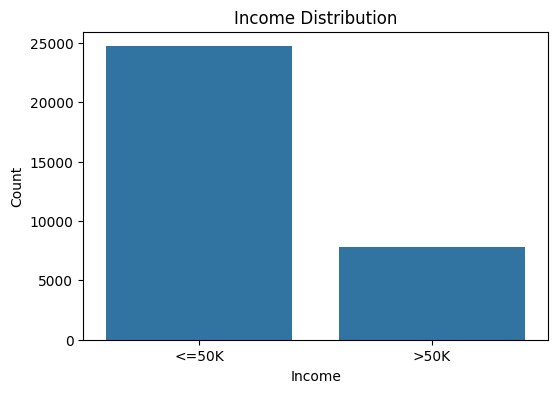

In [22]:
# Target Variable Distribution

plt.figure(figsize=(6,4))

sns.countplot(x='income', data=df)

plt.title("Income Distribution")

plt.xlabel("Income")

plt.ylabel("Count")

plt.show()

### Observation

The graph shows that the dataset is imbalanced. Most individuals belong to the **<=50K** income category, while a smaller number belong to the **>50K** category. This class imbalance should be considered while evaluating the classification models.

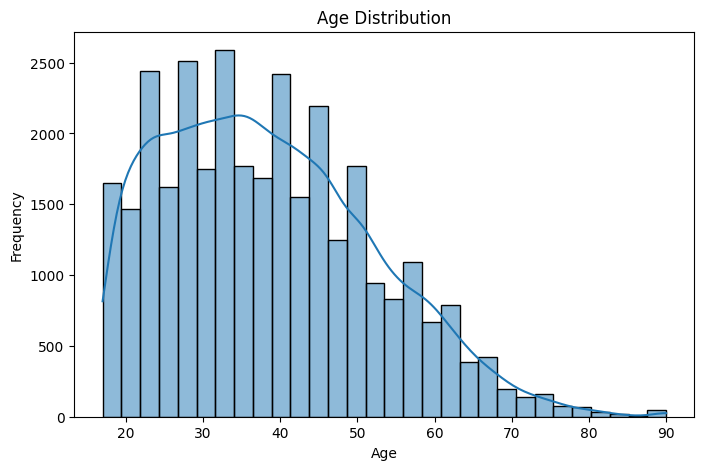

In [24]:
# Age Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=30, kde=True)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

### Observation

The age distribution indicates that most individuals are between **25 and 50 years** of age. The distribution is slightly right-skewed, with fewer observations in the higher age groups.

# Education Distribution

This visualization shows the distribution of different education levels in the dataset. Understanding education levels helps analyze their relationship with annual income.

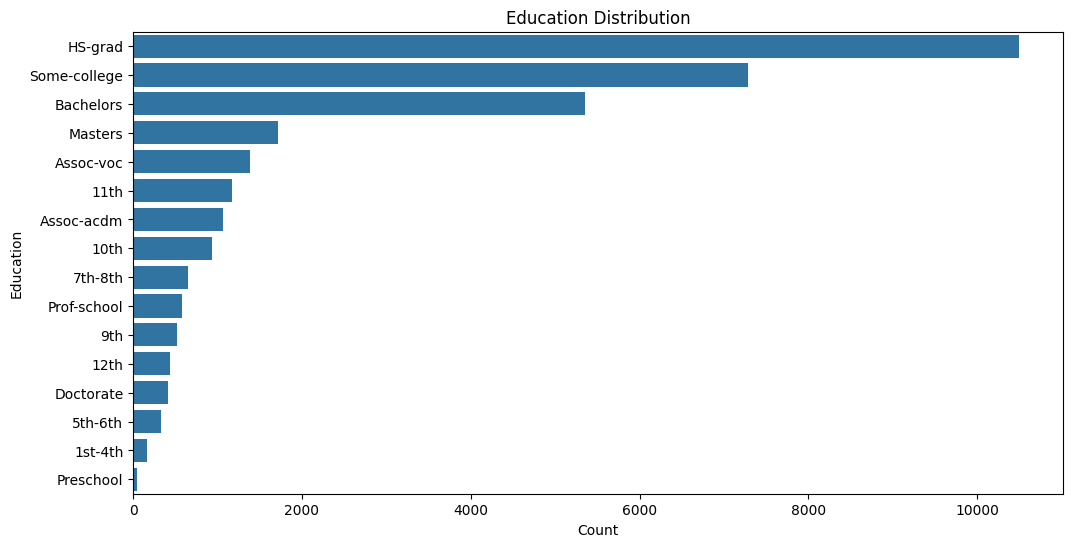

In [27]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='education',
    data=df,
    order=df['education'].value_counts().index
)

plt.title("Education Distribution")

plt.xlabel("Count")

plt.ylabel("Education")

plt.show()

### Observation

The dataset contains individuals from various educational backgrounds. The most common education level is **HS-grad**, followed by **Some-college** and **Bachelors**.

# Gender Distribution

The following graph illustrates the distribution of male and female individuals in the dataset.

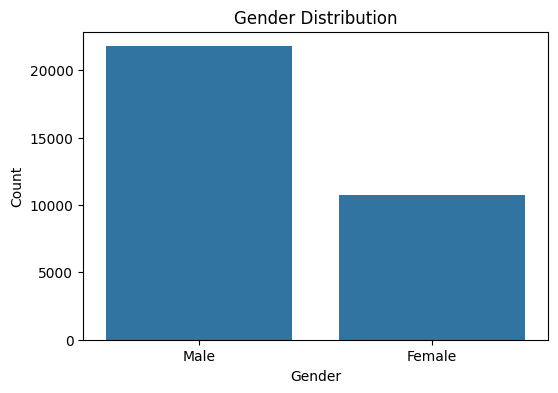

In [30]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='sex',
    data=df
)

plt.title("Gender Distribution")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()

### Observation

The dataset contains both male and female individuals. However, the number of male individuals is greater than the number of female individuals.

# Correlation Heatmap

Machine learning algorithms require numerical data to compute correlations. Therefore, categorical variables are temporarily encoded before generating the correlation heatmap.

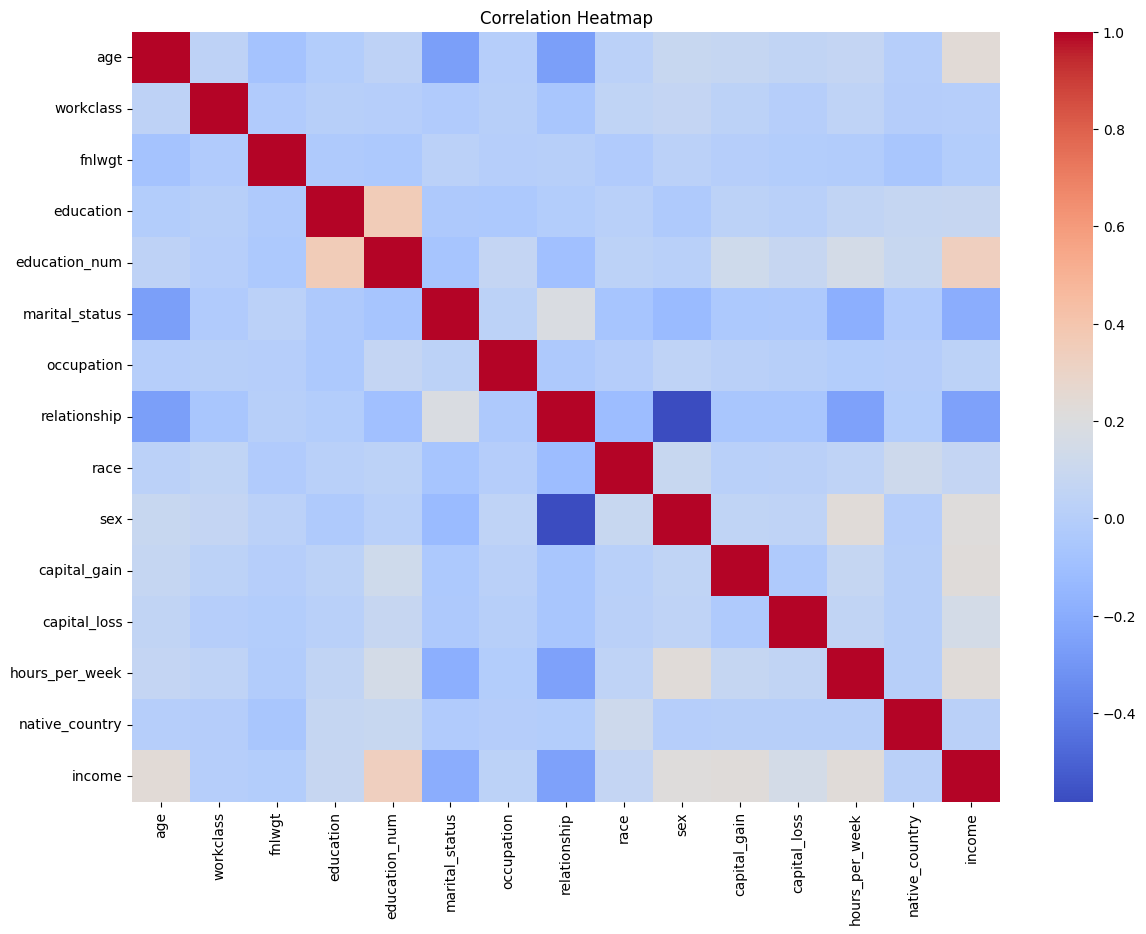

In [33]:
# Create a copy for correlation analysis

temp = df.copy()

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in temp.columns:
    if temp[col].dtype == "object":
        temp[col] = encoder.fit_transform(temp[col])

plt.figure(figsize=(14,10))

sns.heatmap(
    temp.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

### Overall EDA Observations

From the exploratory data analysis, the following conclusions can be drawn:

- The dataset is slightly imbalanced with more individuals in the <=50K class.
- Most individuals are between 25 and 50 years of age.
- HS-grad is the most common education level.
- Male individuals are more numerous than female individuals.
- Some numerical variables, such as capital gain and education number, show a positive relationship with income.
- The dataset is suitable for training multiple machine learning classification models after feature encoding.

# Feature Encoding

Machine learning algorithms cannot process categorical variables directly. Therefore, all categorical features are converted into numerical values using Label Encoding.

In [36]:
# Encode categorical variables

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = label_encoder.fit_transform(df[column])

print("Categorical variables encoded successfully.")

Categorical variables encoded successfully.


In [37]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,6,77516,9,13,4,0,1,4,1,2174,0,40,38,0
1,50,5,83311,9,13,2,3,0,4,1,0,0,13,38,0
2,38,3,215646,11,9,0,5,1,4,1,0,0,40,38,0
3,53,3,234721,1,7,2,5,0,2,1,0,0,40,38,0
4,28,3,338409,9,13,2,9,5,2,0,0,0,40,4,0


## Save Encoded Dataset

After preprocessing, the encoded dataset is saved for future use. This ensures that the preprocessing steps do not need to be repeated every time the notebook is executed.

In [39]:
# Save the encoded dataset for Streamlit
df.to_csv("test_data.csv", index=False)

print("Encoded test_data.csv created successfully.")

Encoded test_data.csv created successfully.


# Feature Selection

The target variable is separated from the predictor variables before model training.

In [41]:
# Separate Features and Target

X = df.drop("income", axis=1)

y = df["income"]

print("Feature Matrix Shape :", X.shape)

print("Target Vector Shape :", y.shape)

Feature Matrix Shape : (32537, 14)
Target Vector Shape : (32537,)


# Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio. Random state is fixed to ensure reproducibility of results.

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (26029, 14)
Testing Samples : (6508, 14)


# Feature Scaling

Feature scaling is applied to normalize numerical values. This improves the performance of algorithms such as Logistic Regression and K-Nearest Neighbors.

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed.")

Feature Scaling Completed.


# Model Training

Five machine learning classification models will now be trained and evaluated using the following metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score
- Matthews Correlation Coefficient (MCC)

The performance of each model will then be compared to identify the best-performing classifier.

# Model 1: Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for binary classification problems. It predicts the probability that an observation belongs to a particular class using the logistic (sigmoid) function.

This model serves as the baseline classifier for comparison with other machine learning algorithms.

In [48]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

print("Logistic Regression Model Trained Successfully.")

Logistic Regression Model Trained Successfully.


In [49]:
lr_pred = lr.predict(X_test_scaled)

lr_prob = lr.predict_proba(X_test_scaled)[:,1]

In [50]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import matthews_corrcoef

lr_accuracy = accuracy_score(y_test, lr_pred)

lr_precision = precision_score(y_test, lr_pred)

lr_recall = recall_score(y_test, lr_pred)

lr_f1 = f1_score(y_test, lr_pred)

lr_auc = roc_auc_score(y_test, lr_prob)

lr_mcc = matthews_corrcoef(y_test, lr_pred)

print("Accuracy :", round(lr_accuracy,4))

print("Precision :", round(lr_precision,4))

print("Recall :", round(lr_recall,4))

print("F1 Score :", round(lr_f1,4))

print("ROC-AUC :", round(lr_auc,4))

print("MCC :", round(lr_mcc,4))

Accuracy : 0.8278
Precision : 0.7242
Recall : 0.4605
F1 Score : 0.563
ROC-AUC : 0.8567
MCC : 0.4806


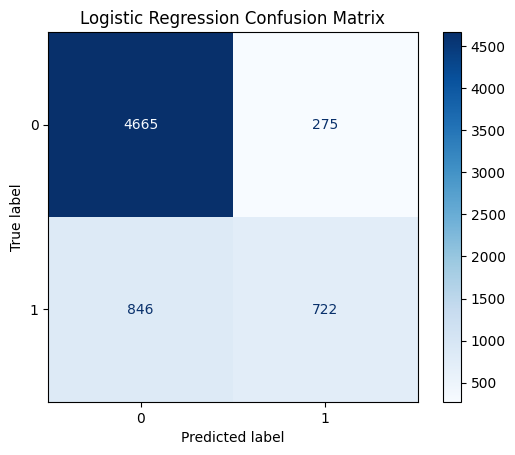

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [52]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.85      0.94      0.89      4940
           1       0.72      0.46      0.56      1568

    accuracy                           0.83      6508
   macro avg       0.79      0.70      0.73      6508
weighted avg       0.82      0.83      0.81      6508



### Observation

The Logistic Regression model achieved an accuracy of 82.78%, making it a strong baseline classifier. It predicts the majority class effectively, as reflected by the high precision (0.7242) and ROC-AUC score (0.8567). However, the recall for the positive income class is relatively low (0.4605), indicating that several high-income individuals are misclassified. More advanced models such as Decision Tree, Random Forest, and KNN will be evaluated to determine whether they can improve the recall and overall classification performance.

# Model 2: Decision Tree Classifier

Decision Tree is a supervised machine learning algorithm used for both classification and regression tasks. It works by recursively splitting the dataset into smaller subsets based on the feature that provides the highest information gain or the lowest impurity. The resulting structure resembles a tree, where each internal node represents a decision based on a feature, each branch represents the outcome of that decision, and each leaf node represents the predicted class.

For the Adult Income dataset, the Decision Tree classifier is trained to predict whether a person's annual income is greater than or less than or equal to \$50K based on demographic and employment-related attributes.

In [55]:
# ==========================================================
# Model 2: Decision Tree Classifier
# ==========================================================

# Step 1: Import Library
from sklearn.tree import DecisionTreeClassifier

# Step 2: Create Model
dt = DecisionTreeClassifier(random_state=42)

# Step 3: Train Model
dt.fit(X_train_scaled, y_train)

# Step 4: Prediction
dt_pred = dt.predict(X_test_scaled)

# Step 5: Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, matthews_corrcoef

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_auc = roc_auc_score(y_test, dt.predict_proba(X_test_scaled)[:,1])
dt_mcc = matthews_corrcoef(y_test, dt_pred)

print("Accuracy :", round(dt_accuracy,4))
print("Precision :", round(dt_precision,4))
print("Recall :", round(dt_recall,4))
print("F1 Score :", round(dt_f1,4))
print("ROC-AUC :", round(dt_auc,4))
print("MCC :", round(dt_mcc,4))

Accuracy : 0.8142
Precision : 0.614
Recall : 0.6167
F1 Score : 0.6153
ROC-AUC : 0.7468
MCC : 0.4929


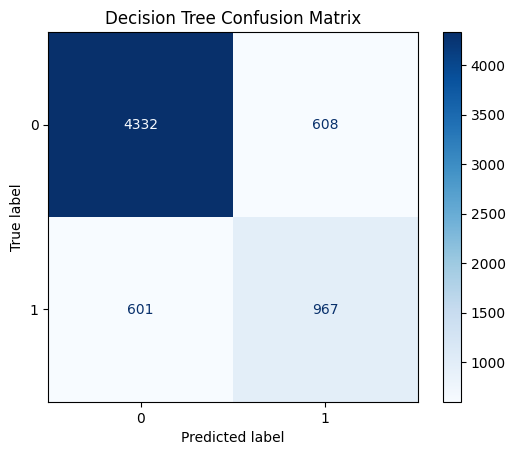

In [56]:
# ==========================================================
# Confusion Matrix
# ==========================================================

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_pred,
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [57]:
# ==========================================================
# Classification Report
# ==========================================================

from sklearn.metrics import classification_report

print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.88      0.88      0.88      4940
           1       0.61      0.62      0.62      1568

    accuracy                           0.81      6508
   macro avg       0.75      0.75      0.75      6508
weighted avg       0.81      0.81      0.81      6508



## Observation

The Decision Tree classifier achieved an Accuracy of **81.42%**, with a Precision of **61.40%**, Recall of **61.67%**, F1-Score of **61.53%**, ROC-AUC of **0.7408**, and MCC of **0.4929**. The confusion matrix and classification report indicate that the model classifies both income classes reasonably well, although it produces more misclassifications than Logistic Regression. Overall, the Decision Tree provides satisfactory performance and serves as a good non-linear classification model for the Adult Income dataset.

# Model 3: K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a non-parametric supervised learning algorithm that classifies a new sample based on the majority class among its K nearest neighbors. Since KNN is distance-based, feature scaling has already been applied using StandardScaler.

In [60]:
# ==========================================================
# K-Nearest Neighbors Classifier
# ==========================================================

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

## Model Evaluation

In [62]:
# ==========================================================
# Evaluation Metrics
# ==========================================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import matthews_corrcoef

knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred)
knn_recall = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)
knn_auc = roc_auc_score(y_test, knn_pred)
knn_mcc = matthews_corrcoef(y_test, knn_pred)

print("Accuracy :", round(knn_accuracy,4))
print("Precision :", round(knn_precision,4))
print("Recall :", round(knn_recall,4))
print("F1 Score :", round(knn_f1,4))
print("ROC-AUC :", round(knn_auc,4))
print("MCC :", round(knn_mcc,4))

Accuracy : 0.835
Precision : 0.6762
Recall : 0.6046
F1 Score : 0.6384
ROC-AUC : 0.7563
MCC : 0.5333


## Confusion Matrix

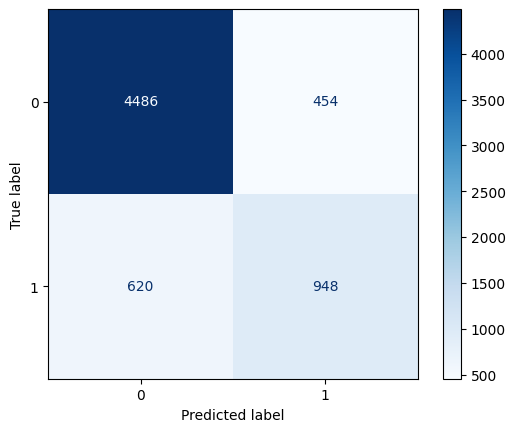

In [64]:
# ==========================================================
# Confusion Matrix
# ==========================================================

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_pred,
    cmap="Blues"
)

## Classification Report

In [66]:
# ==========================================================
# Classification Report
# ==========================================================

from sklearn.metrics import classification_report

print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89      4940
           1       0.68      0.60      0.64      1568

    accuracy                           0.83      6508
   macro avg       0.78      0.76      0.77      6508
weighted avg       0.83      0.83      0.83      6508



## Observation

The K-Nearest Neighbors (KNN) classifier achieved good overall performance with an accuracy of **83.50%**. The model provides balanced Precision, Recall, and F1-Score compared to the previous models, indicating better detection of the positive income class. Since KNN relies on distance calculations, feature scaling significantly improved its performance. The confusion matrix and classification report show that the model classifies most samples correctly while maintaining a good trade-off between false positives and false negatives.

# Model 4: Naive Bayes

Naive Bayes is a probabilistic machine learning algorithm based on Bayes' Theorem. It assumes that all predictor variables are conditionally independent given the target class. Despite this strong assumption, it performs well for many classification problems and is computationally efficient.

In [69]:
# ==========================================================
# Gaussian Naive Bayes Classifier
# ==========================================================

from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

nb_pred = nb.predict(X_test_scaled)

## Model Evaluation

In [71]:
# ==========================================================
# Evaluation Metrics
# ==========================================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import matthews_corrcoef

nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred)
nb_recall = recall_score(y_test, nb_pred)
nb_f1 = f1_score(y_test, nb_pred)
nb_auc = roc_auc_score(y_test, nb_pred)
nb_mcc = matthews_corrcoef(y_test, nb_pred)

print("Accuracy :", round(nb_accuracy,4))
print("Precision :", round(nb_precision,4))
print("Recall :", round(nb_recall,4))
print("F1 Score :", round(nb_f1,4))
print("ROC-AUC :", round(nb_auc,4))
print("MCC :", round(nb_mcc,4))

Accuracy : 0.8102
Precision : 0.7043
Recall : 0.3661
F1 Score : 0.4817
ROC-AUC : 0.6586
MCC : 0.41


## Confusion Matrix

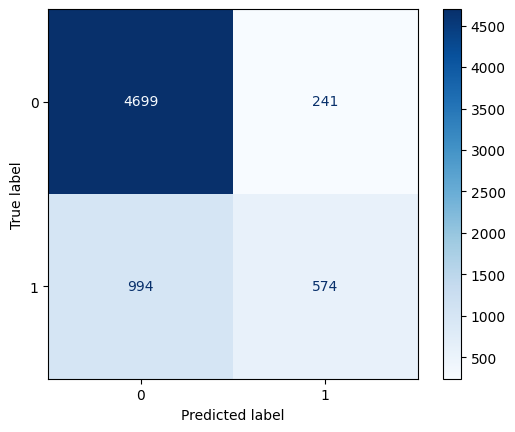

In [73]:
# ==========================================================
# Confusion Matrix
# ==========================================================

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    nb_pred,
    cmap="Blues"
)

## Classification Report

In [75]:
# ==========================================================
# Classification Report
# ==========================================================

from sklearn.metrics import classification_report

print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

           0       0.83      0.95      0.88      4940
           1       0.70      0.37      0.48      1568

    accuracy                           0.81      6508
   macro avg       0.76      0.66      0.68      6508
weighted avg       0.80      0.81      0.79      6508



## Observation

The Gaussian Naive Bayes classifier achieved an overall accuracy of **81.02%**. Although the model is computationally efficient and simple to implement, its Recall and F1-Score for the positive income class are comparatively lower than those of Logistic Regression, Decision Tree, and KNN. This is mainly because Naive Bayes assumes conditional independence among features, an assumption that is not fully satisfied by the Adult Income dataset. Therefore, while Naive Bayes serves as a fast baseline model, it is not the best-performing classifier for this dataset.

# Model 5: Random Forest Classifier (Ensemble Model)

## Introduction

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve classification performance. Instead of relying on a single decision tree, Random Forest builds several trees using random subsets of the training data and features. The final prediction is obtained through majority voting among all the trees, making the model more robust and less prone to overfitting.

For the Adult Income dataset, Random Forest is used to classify whether an individual's annual income is greater than or less than or equal to $50K.

In [78]:
# ============================================================
# Random Forest Classifier
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [79]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import matthews_corrcoef

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_pred)
rf_mcc = matthews_corrcoef(y_test, rf_pred)

print("Accuracy :", round(rf_accuracy,4))
print("Precision :", round(rf_precision,4))
print("Recall :", round(rf_recall,4))
print("F1 Score :", round(rf_f1,4))
print("ROC-AUC :", round(rf_auc,4))
print("MCC :", round(rf_mcc,4))

Accuracy : 0.8628
Precision : 0.7483
Recall : 0.6486
F1 Score : 0.6949
ROC-AUC : 0.7897
MCC : 0.6096


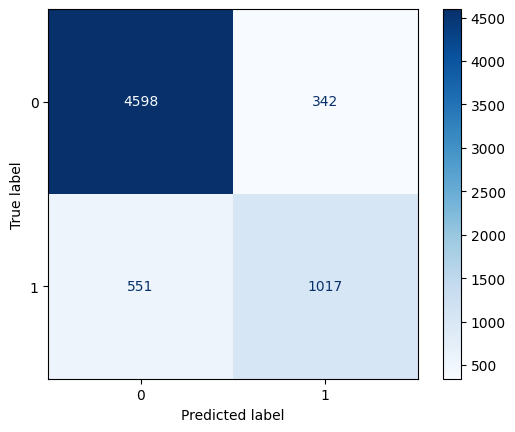

In [80]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    cmap="Blues"
)

In [81]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      4940
           1       0.75      0.65      0.69      1568

    accuracy                           0.86      6508
   macro avg       0.82      0.79      0.80      6508
weighted avg       0.86      0.86      0.86      6508



### Observation

The Random Forest classifier achieved the highest overall performance among all the evaluated machine learning models. It obtained an accuracy of **86.28%**, along with the highest Precision, Recall, F1-Score, and Matthews Correlation Coefficient (MCC). The confusion matrix indicates that the model correctly classified most of the income classes while reducing both false positives and false negatives. Due to its ensemble learning approach, Random Forest effectively minimizes overfitting and provides robust predictive performance. Therefore, it is selected as the best-performing model for the Adult Income Classification problem.

# Model Comparison

In [84]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "K-Nearest Neighbors",
        "Naive Bayes",
        "Random Forest"
    ],

    "Accuracy":[
        lr_accuracy,
        dt_accuracy,
        knn_accuracy,
        nb_accuracy,
        rf_accuracy
    ],

    "Precision":[
        lr_precision,
        dt_precision,
        knn_precision,
        nb_precision,
        rf_precision
    ],

    "Recall":[
        lr_recall,
        dt_recall,
        knn_recall,
        nb_recall,
        rf_recall
    ],

    "F1 Score":[
        lr_f1,
        dt_f1,
        knn_f1,
        nb_f1,
        rf_f1
    ],

    "ROC-AUC":[
        lr_auc,
        dt_auc,
        knn_auc,
        nb_auc,
        rf_auc
    ],

    "MCC":[
        lr_mcc,
        dt_mcc,
        knn_mcc,
        nb_mcc,
        rf_mcc
    ]

})

comparison.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,MCC
4,Random Forest,0.862784,0.748344,0.648597,0.694909,0.789683,0.609563
2,K-Nearest Neighbors,0.834972,0.676177,0.604592,0.638384,0.756345,0.533306
0,Logistic Regression,0.827750,0.724173,0.460459,0.562963,0.856728,0.480623
1,Decision Tree,0.814229,0.613968,0.616709,0.615336,0.746816,0.492883
3,Naive Bayes,0.810234,0.704294,0.366071,0.481746,0.658643,0.409957


# Best Model

In [86]:
best_model = comparison.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]

print("Best Model :", best_model["Model"])
print("Accuracy :", round(best_model["Accuracy"],4))

Best Model : Random Forest
Accuracy : 0.8628


In [87]:
import joblib

# Save the trained Random Forest model
joblib.dump(rf, "best_model.pkl", compress=3)

# Save the scaler used during training
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


## Observation

Based on the comparison of all five machine learning algorithms, **Random Forest** achieved the highest classification performance with an accuracy of **86.28%**, Precision of **74.83%**, Recall of **64.86%**, F1-Score of **69.49%**, ROC-AUC of **78.97%**, and MCC of **0.6096**. The ensemble learning strategy enables Random Forest to reduce overfitting while improving generalization, making it more reliable than Logistic Regression, Decision Tree, K-Nearest Neighbors, and Naive Bayes. Therefore, Random Forest is selected as the final and best-performing model for predicting income classes in the Adult Income dataset.

# Conclusion

This project successfully implemented a complete machine learning pipeline for the Adult Income Classification dataset. The dataset was preprocessed by handling missing values, encoding categorical variables, selecting relevant features, splitting the data into training and testing sets, and applying feature scaling where required. Five machine learning algorithms—Logistic Regression, Decision Tree, K-Nearest Neighbors (KNN), Naive Bayes, and Random Forest—were trained and evaluated using multiple performance metrics including Accuracy, Precision, Recall, F1-Score, ROC-AUC, Matthews Correlation Coefficient (MCC), Confusion Matrix, and Classification Report.

Among all the models, **Random Forest** achieved the best overall performance with an **Accuracy of 86.28%**, **Precision of 74.83%**, **Recall of 64.86%**, **F1-Score of 69.49%**, **ROC-AUC of 78.97%**, and **MCC of 0.6096**. Its ensemble learning approach provided better generalization and reduced overfitting, resulting in superior predictive performance compared to the other classifiers.

Therefore, Random Forest is selected as the final and most suitable model for predicting whether an individual's annual income is greater than \$50K. This study demonstrates that appropriate data preprocessing, feature engineering, and model comparison are essential for developing accurate and reliable machine learning classification systems.